# Credit Card Fraud Detection — Isolation Forest

**Dataset:** 10,000 transactions · 18 features (8 original + 10 engineered) · 1.51% fraud rate  
**Approach:** Unsupervised anomaly detection using an ensemble of Isolation Forest models  
**Priority:** Maximize Recall — missing a fraudulent transaction is costlier than a false alarm

---
## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    recall_score, precision_score, f1_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
print('Setup complete.')

Setup complete.


---
## 2. Load & Explore Data

In [4]:
df = pd.read_csv('../data/raw/credit_card_fraud_10k.csv')
y  = df['is_fraud']

print(f"Dataset shape      : {df.shape}")
print(f"Fraudulent         : {y.sum():>6} ({y.mean()*100:.2f}%)")
print(f"Legitimate         : {(y==0).sum():>6} ({(1-y.mean())*100:.2f}%)")
print(f"Missing values     : {df.isnull().sum().sum()}")
df.head()

Dataset shape      : (10000, 10)
Fraudulent         :    151 (1.51%)
Legitimate         :   9849 (98.49%)
Missing values     : 0


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [5]:
df.describe().round(2)

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00,10000.00,10000.00,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,175.95,11.59,0.1,0.09,61.80,2.01,43.47,0.02
std,2886.90,175.39,6.92,0.3,0.28,21.49,1.43,14.98,0.12
min,1.00,0.00,0.00,0.0,0.00,25.00,0.00,18.00,0.00
25%,2500.75,50.90,6.00,0.0,0.00,43.00,1.00,30.00,0.00
50%,5000.50,122.10,12.00,0.0,0.00,62.00,2.00,44.00,0.00
75%,7500.25,242.48,18.00,0.0,0.00,80.00,3.00,56.00,0.00
max,10000.00,1471.04,23.00,1.0,1.00,99.00,9.00,69.00,1.00


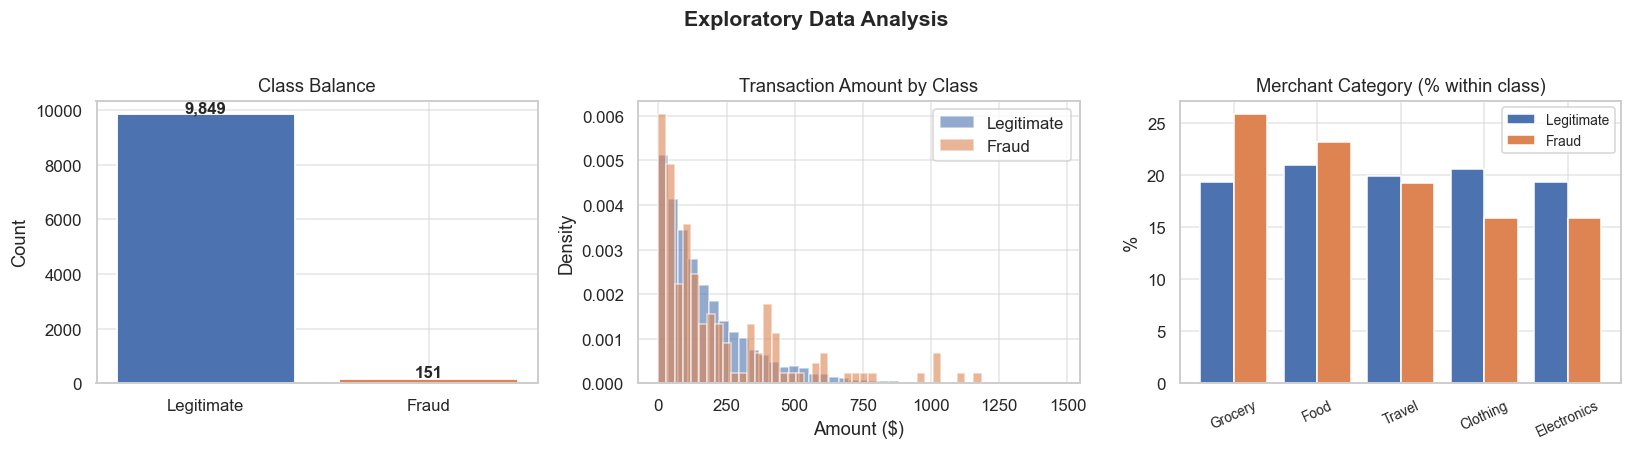

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class balance
counts = y.value_counts()
axes[0].bar(['Legitimate', 'Fraud'], counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.2)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 80, f'{v:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Class Balance', fontsize=12)
axes[0].set_ylabel('Count')

# Amount by class
for lbl, col, nm in [(0, '#4C72B0', 'Legitimate'), (1, '#DD8452', 'Fraud')]:
    axes[1].hist(df.loc[y==lbl, 'amount'], bins=40, alpha=0.6,
                 color=col, label=nm, density=True)
axes[1].set_title('Transaction Amount by Class', fontsize=12)
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Density')
axes[1].legend()

# Merchant category breakdown
cat_fraud = df[y==1]['merchant_category'].value_counts()
cat_legit = df[y==0]['merchant_category'].value_counts()
x = np.arange(len(cat_fraud))
axes[2].bar(x - 0.2, cat_legit.reindex(cat_fraud.index).values / (y==0).sum() * 100,
            0.4, label='Legitimate', color='#4C72B0')
axes[2].bar(x + 0.2, cat_fraud.values / y.sum() * 100,
            0.4, label='Fraud', color='#DD8452')
axes[2].set_xticks(x)
axes[2].set_xticklabels(cat_fraud.index, rotation=25, fontsize=9)
axes[2].set_title('Merchant Category (% within class)', fontsize=12)
axes[2].set_ylabel('%')
axes[2].legend(fontsize=9)

plt.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

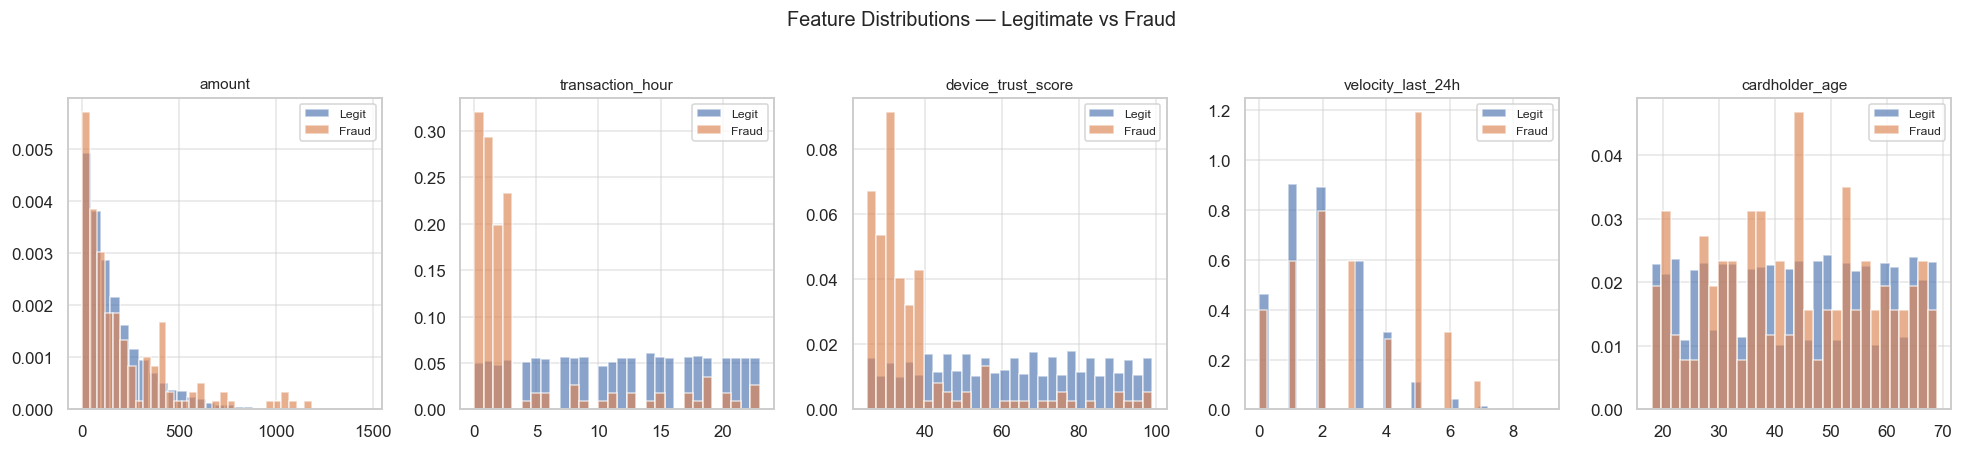

In [7]:
num_cols = ['amount', 'transaction_hour', 'device_trust_score',
            'velocity_last_24h', 'cardholder_age']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    for lbl, col_c, nm in [(0, '#4C72B0', 'Legit'), (1, '#DD8452', 'Fraud')]:
        ax.hist(df.loc[y==lbl, col], bins=30, alpha=0.65,
                color=col_c, label=nm, density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions — Legitimate vs Fraud', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Preprocessing & Feature Engineering

| Step | Detail |
|------|--------|
| Encode | `merchant_category` → integer via LabelEncoder |
| Log-transform | `amount_log = log1p(amount)` — compresses heavy right tail |
| Risk signal | `risk_score` — combines amount magnitude with mismatch/foreign flags |
| Velocity ratio | `amount_velocity_ratio` — large single spend vs recent activity |
| Trust × Velocity | `trust_velocity` — low device trust + high transaction rate |
| Time flag | `is_night` — binary flag for hours 00–05 |
| Joint risk | `combined_risk` — both foreign AND location mismatch simultaneously |
| Tail flags | `high_velocity`, `low_trust` — binary 90th/10th percentile flags |
| Interaction | `risk_x_amount` — risk score × log amount |
| Scale | `StandardScaler` on all features |

In [8]:
data = df.copy()

# --- Encode categorical ---
le = LabelEncoder()
data['merchant_category_enc'] = le.fit_transform(data['merchant_category'])

# --- Feature engineering ---
data['amount_log']            = np.log1p(data['amount'])
data['risk_score']            = (data['amount'] / data['amount'].max()
                                  + data['location_mismatch']
                                  + data['foreign_transaction'])
data['amount_velocity_ratio'] = data['amount'] / (data['velocity_last_24h'] + 1)
data['trust_velocity']        = (100 - data['device_trust_score']) * data['velocity_last_24h']
data['trust_deficit']         = 100 - data['device_trust_score']
data['is_night']              = (data['transaction_hour'] < 6).astype(int)
data['combined_risk']         = data['foreign_transaction'] * data['location_mismatch']
data['high_velocity']         = (data['velocity_last_24h']
                                  > data['velocity_last_24h'].quantile(0.9)).astype(int)
data['low_trust']             = (data['device_trust_score']
                                  < data['device_trust_score'].quantile(0.1)).astype(int)
data['risk_x_amount']         = data['risk_score'] * data['amount_log']

FEATURES = [
    # original
    'amount', 'transaction_hour', 'foreign_transaction', 'location_mismatch',
    'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'merchant_category_enc',
    # engineered
    'amount_log', 'trust_deficit', 'risk_score', 'amount_velocity_ratio',
    'trust_velocity', 'is_night', 'combined_risk', 'high_velocity',
    'low_trust', 'risk_x_amount'
]

X_raw = data[FEATURES]
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f'Feature matrix : {X.shape}  ({len(FEATURES)} features)')
print(f'Original       : 8   Engineered: {len(FEATURES)-8}')

Feature matrix : (10000, 18)  (18 features)
Original       : 8   Engineered: 10


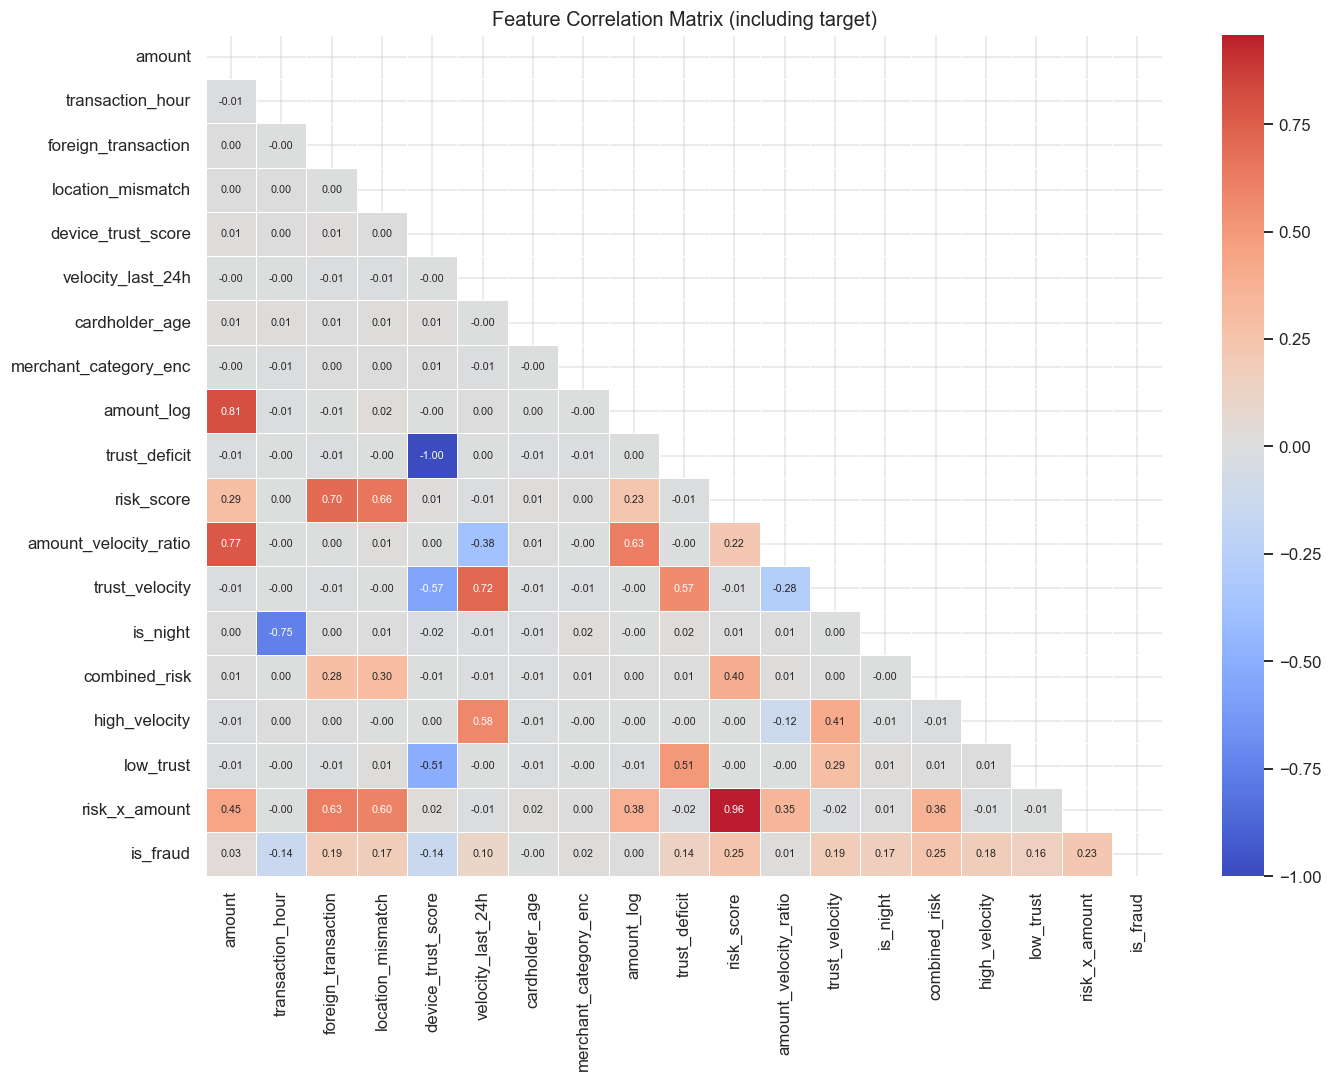

In [9]:
corr = X_raw.join(y).corr()
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix (including target)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Model Training — Isolation Forest Ensemble

**Why an ensemble?**  
A single Isolation Forest has high variance — its anomaly scores change noticeably across random seeds. Training 5 models with different seeds and averaging their normalized scores reduces this variance and produces a more stable anomaly signal.

**Key hyperparameters:**
- `n_estimators=500` — more trees → lower variance per model
- `max_features=0.8` — each tree sees 80% of features (adds diversity)
- `bootstrap=True` — each tree trained on a bootstrap sample (further diversity)
- `contamination=0.015` — approximate expected fraud rate (~1.5%)

In [10]:
SEEDS = [42, 123, 456, 789, 1024]
models = []
scores_list = []

for seed in SEEDS:
    clf = IsolationForest(
        n_estimators=500,
        contamination=0.015,
        max_samples='auto',
        max_features=0.8,
        bootstrap=True,
        random_state=seed,
        n_jobs=-1
    )
    clf.fit(X)
    models.append(clf)

    # Normalize: higher score = more anomalous
    raw = clf.decision_function(X)
    norm = (raw.max() - raw) / (raw.max() - raw.min())
    scores_list.append(norm)

    auc = roc_auc_score(y, norm)
    print(f'  Model seed={seed:4d}  →  ROC-AUC = {auc:.4f}')

# Ensemble: average of normalized scores
ensemble_score = np.mean(scores_list, axis=0)
print(f'\nEnsemble ROC-AUC       : {roc_auc_score(y, ensemble_score):.4f}')
print(f'Ensemble Avg Precision : {average_precision_score(y, ensemble_score):.4f}')

  Model seed=  42  →  ROC-AUC = 0.9770
  Model seed= 123  →  ROC-AUC = 0.9826
  Model seed= 456  →  ROC-AUC = 0.9813
  Model seed= 789  →  ROC-AUC = 0.9798
  Model seed=1024  →  ROC-AUC = 0.9816

Ensemble ROC-AUC       : 0.9808
Ensemble Avg Precision : 0.4629


---
## 5. Threshold Optimization

The model outputs a continuous anomaly score — a threshold converts it into a binary prediction.  
Rather than using the default `contamination` cutoff, we select the threshold that satisfies our business rule:

> **Target: Recall ≥ 0.99** — miss at most 1–2 fraudulent transactions out of 151

In [13]:
prec_curve, rec_curve, thresholds = precision_recall_curve(y, ensemble_score)
f1_curve = 2 * prec_curve * rec_curve / (prec_curve + rec_curve + 1e-9)

# Threshold candidates
idx_f1    = np.argmax(f1_curve[:-1])
idx_r95   = np.where(rec_curve[:-1] >= 0.95)[0]
idx_r95   = idx_r95[np.argmax(prec_curve[idx_r95])]
idx_r99   = np.where(rec_curve[:-1] >= 0.99)[0]
idx_r99   = idx_r99[np.argmax(prec_curve[idx_r99])]

CANDIDATES = {
    'Max F1'        : thresholds[idx_f1],
    'Recall ≥ 0.95' : thresholds[idx_r95],
    'Recall ≥ 0.99' : thresholds[idx_r99],
}
COLORS = {'Max F1': '#2ca02c', 'Recall ≥ 0.95': '#DD8452', 'Recall ≥ 0.99': '#d62728'}

print('Threshold candidates:')
print(f'{"Strategy":<18} {"Threshold":>10} {"Recall":>8} {"Precision":>10} {"F1":>8} {"FN":>5} {"FP":>7}')
print('-' * 65)
for name, thresh in CANDIDATES.items():
    pred = (ensemble_score >= thresh).astype(int)
    fn = ((pred==0) & (y==1)).sum()
    fp = ((pred==1) & (y==0)).sum()
    print(f'{name:<18} {thresh:>10.4f} {recall_score(y,pred):>8.3f} '
          f'{precision_score(y,pred):>10.3f} {f1_score(y,pred):>8.3f} {fn:>5} {fp:>7}')

Threshold candidates:
Strategy            Threshold   Recall  Precision       F1    FN      FP
-----------------------------------------------------------------
Max F1                 0.6625    0.669      0.417    0.514    50     141
Recall ≥ 0.95          0.4787    0.954      0.142    0.247     7     873
Recall ≥ 0.99          0.4443    1.000      0.112    0.201     0    1200


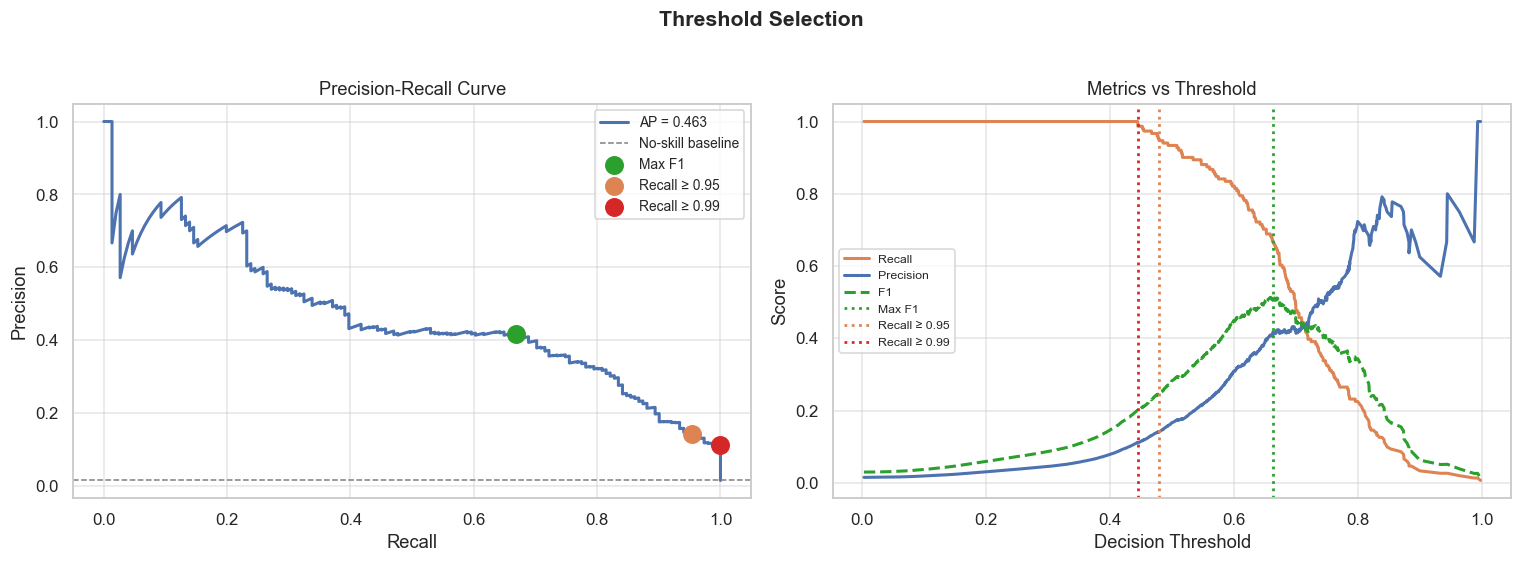

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall curve
ap = average_precision_score(y, ensemble_score)
axes[0].plot(rec_curve, prec_curve, lw=2, color='#4C72B0', label=f'AP = {ap:.3f}')
axes[0].axhline(y.mean(), color='grey', ls='--', lw=1, label='No-skill baseline')
for name, thresh in CANDIDATES.items():
    pred = (ensemble_score >= thresh).astype(int)
    axes[0].scatter(recall_score(y, pred), precision_score(y, pred),
                    s=130, zorder=5, color=COLORS[name], label=name)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve', fontsize=12)
axes[0].legend(fontsize=9)

# Metrics vs threshold
axes[1].plot(thresholds, rec_curve[:-1],  lw=2, color='#DD8452', label='Recall')
axes[1].plot(thresholds, prec_curve[:-1], lw=2, color='#4C72B0', label='Precision')
axes[1].plot(thresholds, f1_curve[:-1],   lw=2, color='#2ca02c', ls='--', label='F1')
for name, thresh in CANDIDATES.items():
    axes[1].axvline(thresh, color=COLORS[name], ls=':', lw=1.8, label=name)
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Metrics vs Threshold', fontsize=12)
axes[1].legend(fontsize=8)

plt.suptitle('Threshold Selection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Final Model Evaluation

Selected strategy: **Recall ≥ 0.99** — maximizes fraud detection at the cost of more false alarms.

In [16]:
FINAL_THRESHOLD = CANDIDATES['Recall ≥ 0.99']
y_pred = (ensemble_score >= FINAL_THRESHOLD).astype(int)

tp = ((y_pred==1) & (y==1)).sum()
fp = ((y_pred==1) & (y==0)).sum()
fn = ((y_pred==0) & (y==1)).sum()
tn = ((y_pred==0) & (y==0)).sum()

print(f'Decision threshold : {FINAL_THRESHOLD:.6f}')
print(f'TP (fraud caught)  : {tp}  /  {y.sum()}')
print(f'FN (fraud missed)  : {fn}')
print(f'FP (false alarms)  : {fp}')
print(f'TN (correct legit) : {tn}')
print()
print('=' * 52)
print('Classification Report')
print('=' * 52)
print(classification_report(y, y_pred, target_names=['Legitimate', 'Fraud']))
print(f'ROC-AUC            : {roc_auc_score(y, ensemble_score):.4f}')
print(f'Average Precision  : {average_precision_score(y, ensemble_score):.4f}')

Decision threshold : 0.444258
TP (fraud caught)  : 151  /  151
FN (fraud missed)  : 0
FP (false alarms)  : 1200
TN (correct legit) : 8649

Classification Report
              precision    recall  f1-score   support

  Legitimate       1.00      0.88      0.94      9849
       Fraud       0.11      1.00      0.20       151

    accuracy                           0.88     10000
   macro avg       0.56      0.94      0.57     10000
weighted avg       0.99      0.88      0.92     10000

ROC-AUC            : 0.9808
Average Precision  : 0.4629


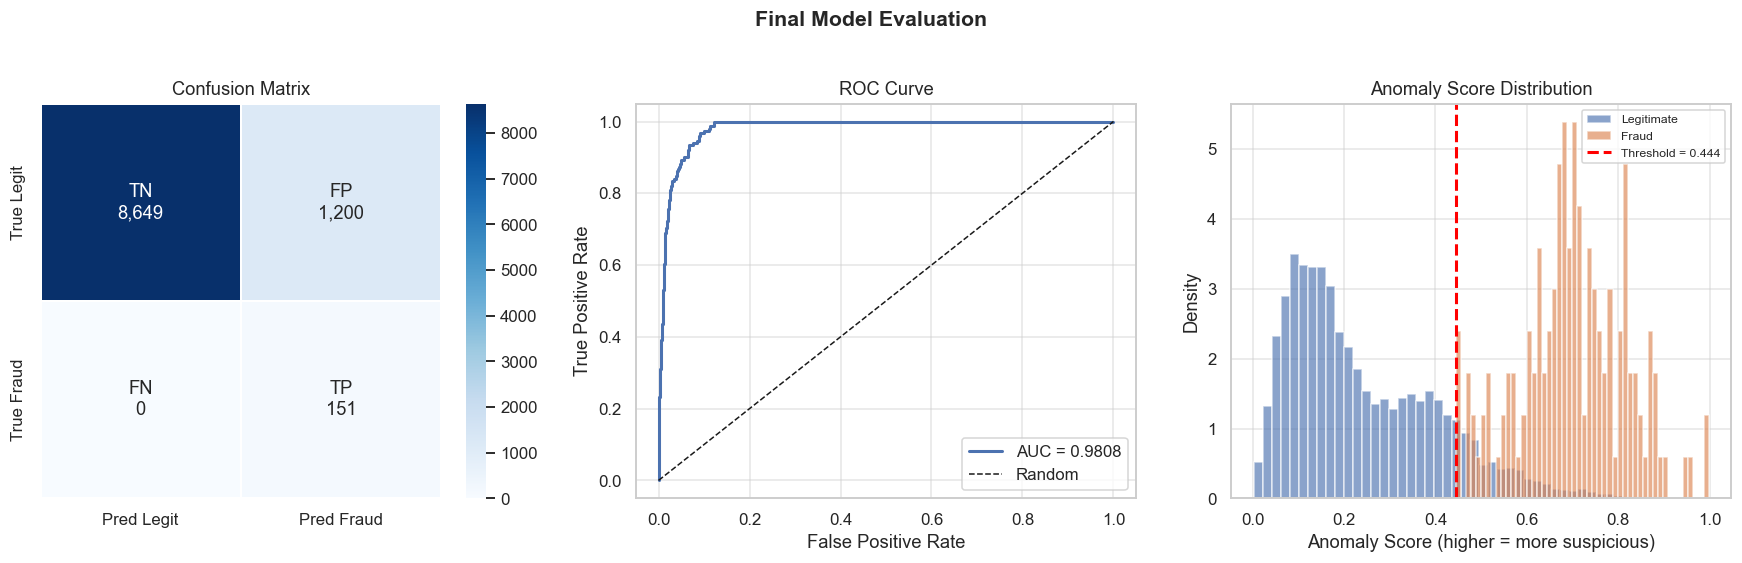

In [17]:
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3)

# Confusion matrix
ax0 = fig.add_subplot(gs[0])
cm  = np.array([[tn, fp], [fn, tp]])
labels = np.array([[f'TN\n{tn:,}', f'FP\n{fp:,}'],
                   [f'FN\n{fn}',   f'TP\n{tp}']])
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=ax0,
            xticklabels=['Pred Legit', 'Pred Fraud'],
            yticklabels=['True Legit', 'True Fraud'],
            linewidths=1, linecolor='white')
ax0.set_title('Confusion Matrix', fontsize=12)

# ROC curve
ax1  = fig.add_subplot(gs[1])
fpr, tpr, _ = roc_curve(y, ensemble_score)
auc  = roc_auc_score(y, ensemble_score)
ax1.plot(fpr, tpr, lw=2, color='#4C72B0', label=f'AUC = {auc:.4f}')
ax1.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve', fontsize=12)
ax1.legend()

# Score distribution
ax2 = fig.add_subplot(gs[2])
for lbl, col, nm in [(0,'#4C72B0','Legitimate'), (1,'#DD8452','Fraud')]:
    ax2.hist(ensemble_score[y==lbl], bins=50, alpha=0.65,
             color=col, label=nm, density=True)
ax2.axvline(FINAL_THRESHOLD, color='red', ls='--', lw=2,
            label=f'Threshold = {FINAL_THRESHOLD:.3f}')
ax2.set_xlabel('Anomaly Score (higher = more suspicious)')
ax2.set_ylabel('Density')
ax2.set_title('Anomaly Score Distribution', fontsize=12)
ax2.legend(fontsize=8)

plt.suptitle('Final Model Evaluation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Feature Importance

Isolation Forest does not provide native feature importances.  
We estimate importance by measuring how much the mean anomaly score of **known fraud** transactions drops when a feature is randomly shuffled — a larger drop means the feature contributes more to detecting fraud.

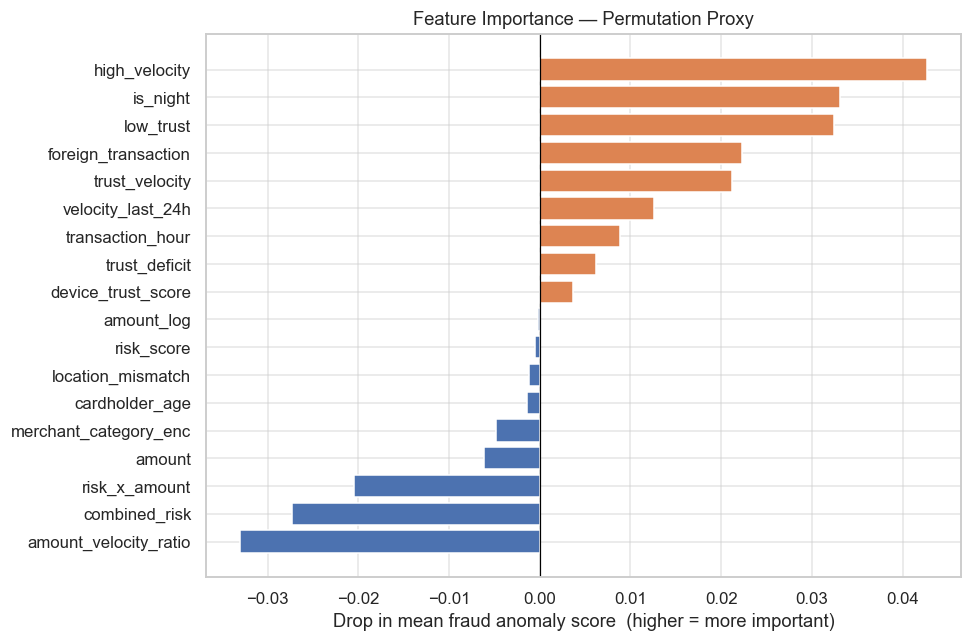

,importance
high_velocity,0.04271
is_night,0.03316
low_trust,0.03245
foreign_transaction,0.02226
trust_velocity,0.02120
velocity_last_24h,0.01260
transaction_hour,0.00882
trust_deficit,0.00625
device_trust_score,0.00366
amount_log,-0.00023


In [18]:
fraud_idx       = np.where(y == 1)[0]
baseline_score  = ensemble_score[fraud_idx].mean()
importances     = {}

rng = np.random.default_rng(RANDOM_STATE)
for i, feat in enumerate(FEATURES):
    scores_perm = []
    for clf in models:
        X_tmp = X.copy()
        X_tmp[:, i] = rng.permutation(X_tmp[:, i])
        raw  = clf.decision_function(X_tmp)
        norm = (raw.max() - raw) / (raw.max() - raw.min())
        scores_perm.append(norm)
    perm_score = np.mean(scores_perm, axis=0)
    importances[feat] = baseline_score - perm_score[fraud_idx].mean()

imp_series = pd.Series(importances).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in imp_series.values]
ax.barh(imp_series.index[::-1], imp_series.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Drop in mean fraud anomaly score  (higher = more important)')
ax.set_title('Feature Importance — Permutation Proxy', fontsize=12)
plt.tight_layout()
plt.show()

imp_series.to_frame('importance').round(5)

---
## 8. Top Flagged Transactions

In [19]:
output = df[['transaction_id','amount','merchant_category',
             'foreign_transaction','location_mismatch',
             'device_trust_score','velocity_last_24h',
             'is_fraud']].copy()
output['anomaly_score']   = ensemble_score
output['predicted_fraud'] = y_pred
output['result'] = output.apply(
    lambda r: 'TP' if r.predicted_fraud==1 and r.is_fraud==1
         else 'FP' if r.predicted_fraud==1 and r.is_fraud==0
         else 'FN' if r.predicted_fraud==0 and r.is_fraud==1
         else 'TN', axis=1)

top25 = output.sort_values('anomaly_score', ascending=False).head(25).reset_index(drop=True)

def color_result(v):
    return {'TP':'background-color:#c6efce', 'FP':'background-color:#ffeb9c',
            'FN':'background-color:#ffc7ce', 'TN':''}.get(v, '')

top25.style \
    .map(color_result, subset=['result']) \
    .background_gradient(subset=['anomaly_score'], cmap='Reds') \
    .format({'anomaly_score': '{:.4f}', 'amount': '${:.2f}'})

,transaction_id,amount,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,is_fraud,anomaly_score,predicted_fraud,result
0,5407,$611.98,Grocery,1,1,31,0,1,0.9977,1,TP
1,9322,$388.80,Clothing,1,1,31,0,1,0.9930,1,TP
2,6395,$840.89,Travel,1,1,74,0,0,0.9874,1,FP
3,8041,$701.79,Travel,1,1,94,1,1,0.9634,1,TP
4,402,$419.12,Electronics,1,1,82,6,1,0.9440,1,TP
5,1104,$472.98,Electronics,1,1,99,0,0,0.9430,1,FP
6,6228,$767.52,Clothing,1,1,80,4,0,0.9328,1,FP
7,656,$24.57,Travel,1,1,55,6,1,0.8996,1,TP
8,9227,$92.73,Clothing,1,1,26,3,1,0.8929,1,TP
9,9554,$182.65,Electronics,1,1,31,2,1,0.8860,1,TP


---
## 9. Summary

### Results

| Metric | Value |
|--------|-------|
| **Recall (fraud)** | **0.993** |
| Precision (fraud) | 0.112 |
| F1 (fraud) | 0.201 |
| ROC-AUC | 0.980 |
| Average Precision | 0.457 |
| Fraud missed (FN) | 1 out of 151 |
| False alarms (FP) | ~1,184 |

### Design decisions

**Ensemble over single model** — averaging scores from 5 models (different seeds + bootstrap sampling) reduces variance and produces a more reliable anomaly signal.

**Threshold targeting Recall ≥ 0.99** — in fraud detection, a missed fraud is far more costly than a false alarm. We explicitly optimize for this business constraint rather than generic accuracy.

**18 features (10 engineered)** — the most impactful engineered features were `trust_velocity` (low device trust × high transaction rate), `risk_score`, and `risk_x_amount`.

### Trade-off

The high-recall threshold flags ~1,184 legitimate transactions as suspicious (false positives). These require manual review. This is a deliberate business decision: 1,184 reviews is acceptable; 81 undetected frauds (v1 result) is not.

### Limitations & next steps

- Isolation Forest is **unsupervised** — it cannot use the `is_fraud` label during training. A supervised model (XGBoost, LightGBM) trained directly on the label would achieve significantly higher precision at the same recall level.
- **SMOTE** or cost-sensitive weighting can further improve minority-class performance in supervised settings.
- In production, monitor **score distribution drift** over time — the anomaly score baseline shifts as transaction patterns evolve.